In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import astropy.constants as const

from accomp import class_Planet, class_Star, class_Disk, class_Molecule

In [2]:
st = class_Star.Star(mass=1.2, ref_abund='Asplund2009')

In [ ]:
#assume simulated measurements based on AF Lep b
pl_measurements = {}
pl_measurements['S'] = np.random.normal(5.7, 0.8, 10000)
pl_measurements['C'] = np.random.normal(3.5, 0.5, 10000)
CtoO_simulated = np.random.normal(0.8, 0.05, 10000)
pl_measurements['O'] = pl_measurements['C'] / CtoO_simulated #np.random.normal(4.4, 0.6, 10000)

In [85]:
mol_dict = class_Molecule.MoleculeDict(st)
mol_dict.set_default_composition()

Putting remaining element fraction for C in refractory
Putting remaining element fraction for O in refractory
Putting remaining element fraction for S in refractory


In [86]:
disk = class_Disk.Disk(st)
disk.set_temp_struct()
solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=50.)

In [87]:
mol_dict.get_mol_Tcond()

{'Al': 2000.0,
 'Ca': 2000.0,
 'Si': 1600.0,
 'Mg': 1600.0,
 'Fe': 1600.0,
 'Ni': 1600.0,
 'O_refractory': 1600.0,
 'Na': 1100.0,
 'NH4SH': 300.0,
 'C_refactory': 300.0,
 'S_refactory': 300.0,
 'H2O': 170.0,
 'H2S': 90.0,
 'CO2': 70.0,
 'NH3': 70.0,
 'CO': 30.0,
 'N2': 25.0,
 'Ne': 25.0,
 'Ar': 25.0}

In [88]:
#temperature at AF Lep b's location
disk.get_location_temperature(9.)

61.624498319194565

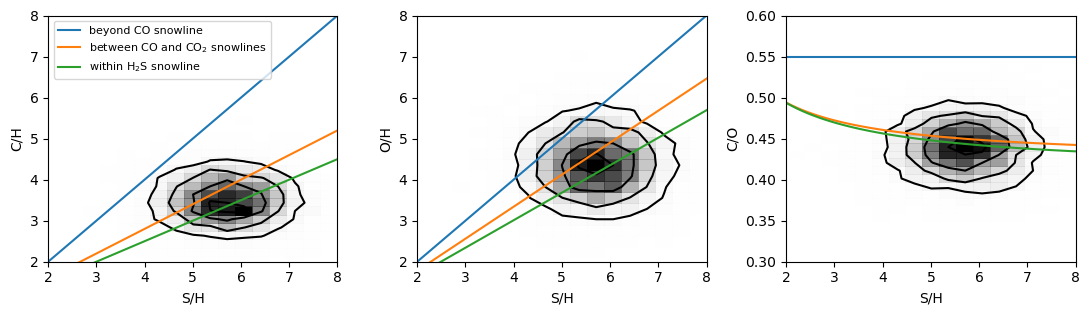

In [89]:
S_to_H_vary = np.logspace(0., 1.)

T_arr = np.array([25., 50., 130.])
lbls_arr = np.array(['beyond CO snowline', 'between CO and CO$_2$ snowlines', 'within H$_2$S snowline'])

# unique_Tcond = np.unique(list(mol_dict.get_mol_Tcond().values()))
# T_arr = 0.5 * (unique_Tcond[1:] + unique_Tcond[:-1])
# T_arr = np.append(min(unique_Tcond) - 5., T_arr)
# T_arr = T_arr[:-3]

fig, axs = plt.subplots(ncols=3, figsize=(11, 3.25), sharex=True)

corner.hist2d(pl_measurements['S'], pl_measurements['C'], ax=axs[0], plot_datapoints=False)
corner.hist2d(pl_measurements['S'], pl_measurements['O'], ax=axs[1], plot_datapoints=False)
corner.hist2d(pl_measurements['S'], pl_measurements['C'] / pl_measurements['O'] * st.CtoO, ax=axs[2], plot_datapoints=False)

for t, temp in enumerate(T_arr):
    solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=temp)
    predicted_comp = disk.assemble_planet(S_to_H_vary, solid_comp, gas_comp)

    axs[0].plot(S_to_H_vary, predicted_comp['C'], label=lbls_arr[t])
    axs[1].plot(S_to_H_vary, predicted_comp['O'])
    axs[2].plot(S_to_H_vary, predicted_comp['C'] / predicted_comp['O'] * st.CtoO)


axs[0].legend(fontsize=8)
axs[0].set_xlim(2, 8)
axs[0].set_ylim(2, 8)
axs[0].set_xlabel('S/H')
axs[0].set_ylabel('C/H')

axs[1].set_ylim(2, 8)
axs[1].set_xlabel('S/H')
axs[1].set_ylabel('O/H')

axs[2].set_ylim(0.3, 0.6)
axs[2].set_xlabel('S/H')
axs[2].set_ylabel('C/O')

fig.tight_layout()
#plt.savefig('formation-composition-links.pdf', bbox_inches='tight')

In [ ]:
solid_comp, gas_comp = disk.get_solid_gas_composition(mol_dict, temp=60.) #at a temperature comparable to the one expected at the planet's location

In [ ]:
solid_comp['S'] #with the assumed composition of disk solids and gas, sulfur is entirely in the solids at 9 au.

1.0

Since S may not be a perfect tracer of refractories and much of the mass fraction of metals is contained in Fe, Mg, and Si, we add 'measurements' of these elemental species to our planet's inventory to get a better estimate of the metal mass of the planet.

If all of S is in solids, then these added enrichments of Fe, Mg, and Si will just be the same as S. If we are in a region of the disk where S is not fully in solids, then we need to account for the < 1 fraction of S in solids while calculating expected enrichment of Fe, Mg, and Si.

In [92]:
pl_measurements['Fe'] = (pl_measurements['S'] - (1 - solid_comp['S'])) / solid_comp['S']
pl_measurements['Mg'] = (pl_measurements['S'] - (1 - solid_comp['S'])) / solid_comp['S']
pl_measurements['Si'] = (pl_measurements['S'] - (1 - solid_comp['S'])) / solid_comp['S']

In [93]:
planet = class_Planet.Planet(st, pl_measurements)
planet.set_planet_mass(3.5, 0.5)
planet.get_metal_mass()

In [94]:
planet.__dict__.keys()

dict_keys(['star', 'measured_abund', 'species_name', 'abund_dict', 'mass_averaged_enrichment', 'mass_fraction', 'mass', 'metal_mass'])

[44.39168298 53.50460499 63.42381165]


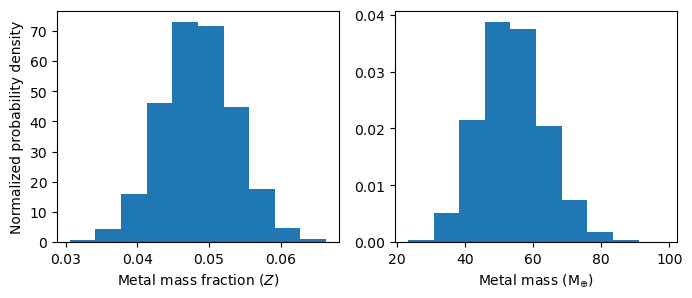

In [95]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 3))
axs[0].hist(planet.mass_fraction[2], density=True)
axs[1].hist(planet.metal_mass * const.M_jup.value/const.M_earth.value, density=True)

axs[0].set_ylabel('Normalized probability density')

axs[0].set_xlabel('Metal mass fraction ($Z$)')
axs[1].set_xlabel('Metal mass (M$_{\\oplus}$)')

print(np.percentile(planet.metal_mass * const.M_jup.value/const.M_earth.value, [16, 50, 84]))

#plt.savefig('Metal-mass-constraints.pdf', bbox_inches='tight')

In [96]:
planet.get_metal_mass_breakdown(solid_comp, gas_comp, 'Fe')

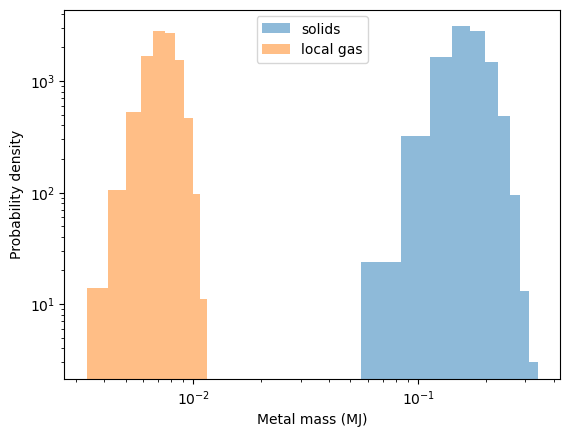

In [ ]:
plt.figure()
plt.hist(planet.metal_mass_solids, log=True, alpha=0.5, label='solids')
plt.hist(planet.metal_mass_local_gas, log=True, alpha=0.5, label='local gas')
#plt.hist(planet.metal_mass_excess_metal, alpha=0.5, label='excess metal') #in this case, we do not need excess metals since local material explains the abundance patterns that are observed

plt.xlabel('Metal mass (MJ)')
plt.ylabel('Probability density')
plt.xscale('log')
plt.legend()

#plt.savefig('metal-mass-breakdown.pdf', bbox_inches='tight')